In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import joblib

from ucimlrepo import fetch_ucirepo 
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
PrecisionRecallDisplay
)
from sklearn.ensemble import RandomForestClassifier
from skorch import NeuralNetClassifier
from skorch.callbacks import EarlyStopping, GradientNormClipping
from skorch.helper import predefined_split

### Data Fetching and Processing

In [2]:
try:
    dataset = fetch_ucirepo(id=350)
    X = dataset.data.features
    y = dataset.data.targets
    df = pd.concat([X, y], axis=1)
    df.columns = dataset.variables['description'].tolist()[1:]
    print("Sucessfully fetced dataset from ucirepo.")
except Exception as e:
    df = pd.read_csv('default_of_credit_card_clients.csv')
    print(f"Ucirepo failed: {e}. Uploaded data from local environment.")
    df.columns = df.iloc[0]
    df = df.iloc[1:].copy()

Sucessfully fetced dataset from ucirepo.


In [3]:
df = df.rename(columns={"default payment next month": "default"})

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remap undocumented EDUCATION categories (0, 5, 6 → 4 "Others") and
# MARRIAGE category 0 → 3 "Others" so indices are contiguous and meaningful
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"]  = df["MARRIAGE"].replace({0: 3})

df = df.reset_index(drop=True)

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Rows: 30,000   Columns: 24
Missing values: 0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Data Exploration

Class Distribution
  No Default (0) : 23,364  (77.88%)
  Default    (1) : 6,636  (22.12%)


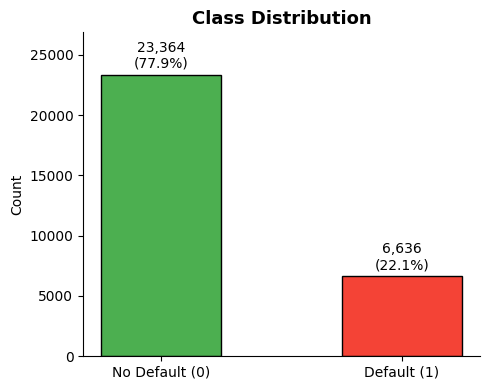

In [4]:
counts = df["default"].value_counts()
pcts   = df["default"].value_counts(normalize=True) * 100

print("Class Distribution")
print(f"  No Default (0) : {counts[0]:,}  ({pcts[0]:.2f}%)")
print(f"  Default    (1) : {counts[1]:,}  ({pcts[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["No Default (0)", "Default (1)"], counts,
              color=["#4CAF50", "#F44336"], edgecolor="black", width=0.5)
for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig("output/class_distribution.png")
plt.show()

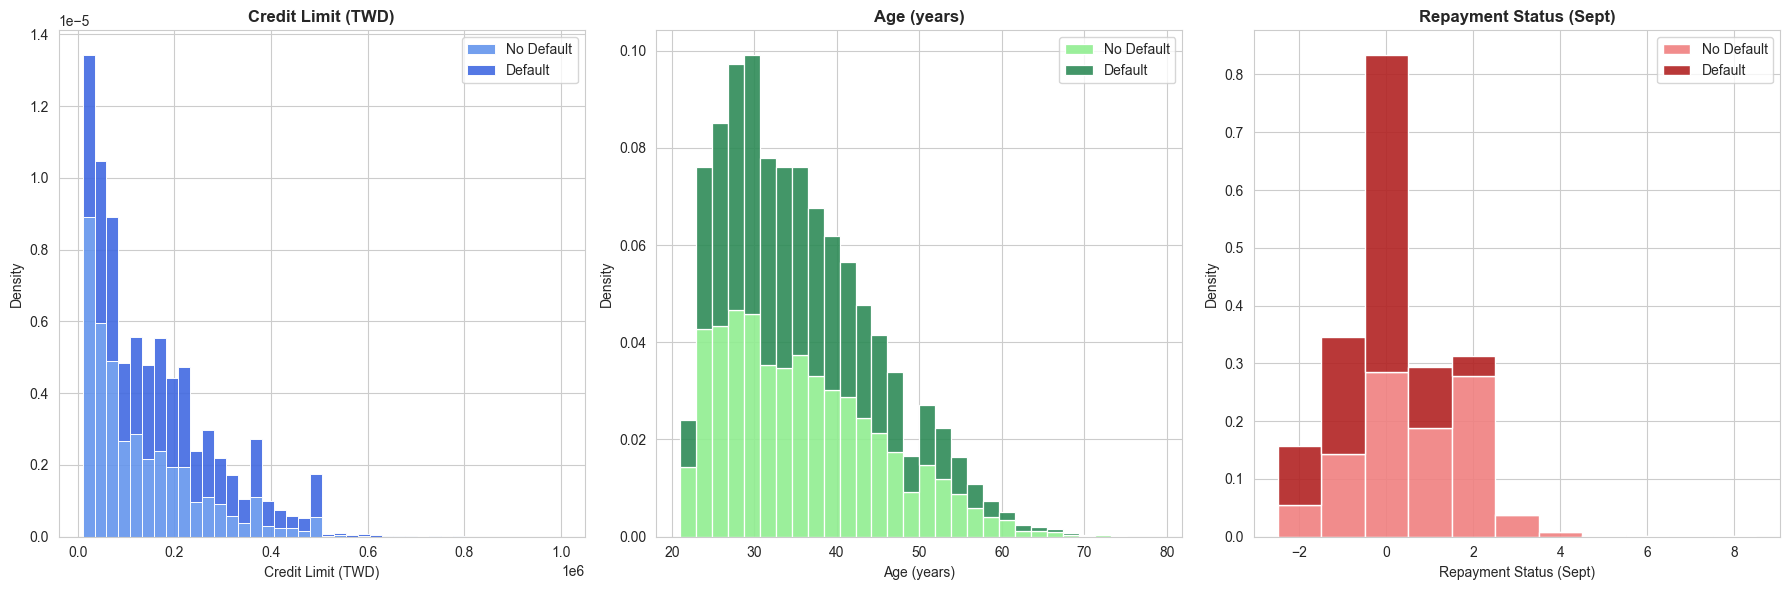

In [5]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(data=df, x='LIMIT_BAL', hue='default', 
             multiple="stack", stat='density', 
             common_norm=False, element="bars", bins=40, 
             palette=['royalblue', 'cornflowerblue'],
             ax=axes[0], alpha=0.9, edgecolor=None)
axes[0].set_title('Credit Limit (TWD)', fontweight='bold')
axes[0].set_xlabel('Credit Limit (TWD)')
axes[0].set_ylabel('Density')
axes[0].legend(title='', labels=['No Default', 'Default'])

sns.histplot(data=df, x='AGE', hue='default', 
             multiple="stack", stat='density', 
             common_norm=False, element="bars", bins=30,
             palette=['seagreen', 'lightgreen'],
             ax=axes[1], alpha=0.9, edgecolor=None)
axes[1].set_title('Age (years)', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density')
axes[1].legend(title='', labels=['No Default', 'Default'])

sns.histplot(data=df, x='PAY_0', hue='default', 
             multiple="stack", stat='density', 
             common_norm=False, element="bars", 
             palette=['firebrick', 'lightcoral'],
             ax=axes[2], alpha=0.9, discrete=True)
axes[2].set_title('Repayment Status (Sept)', fontweight='bold')
axes[2].set_xlabel('Repayment Status (Sept)')
axes[2].set_ylabel('Density')
axes[2].legend(title='', labels=['No Default', 'Default'])

plt.tight_layout()
plt.savefig("output/feature_distributions.png")
plt.show()

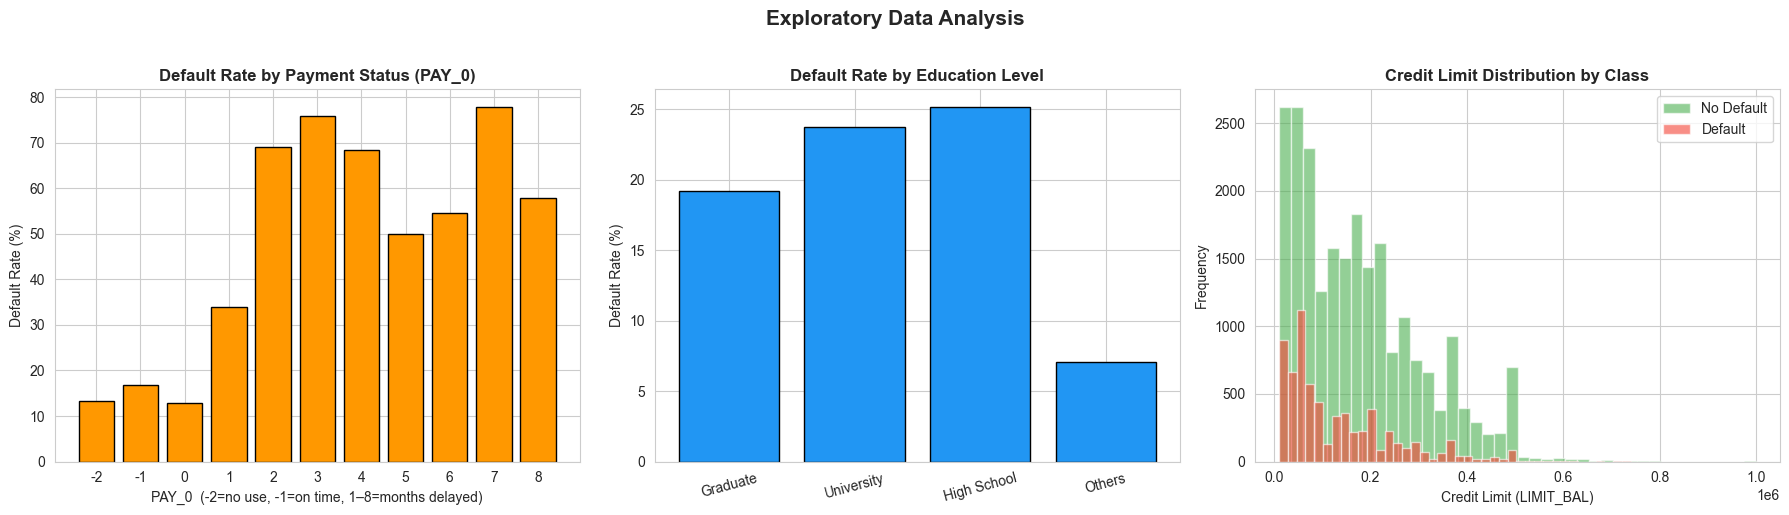

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pay_dr = df.groupby("PAY_0")["default"].mean() * 100
axes[0].bar(pay_dr.index.astype(str), pay_dr.values,
            color="#FF9800", edgecolor="black")
axes[0].set_title("Default Rate by Payment Status (PAY_0)", fontweight="bold")
axes[0].set_xlabel("PAY_0  (-2=no use, -1=on time, 1–8=months delayed)")
axes[0].set_ylabel("Default Rate (%)")

edu_labels = {1: "Graduate", 2: "University", 3: "High School", 4: "Others"}
edu_dr = df.groupby("EDUCATION")["default"].mean() * 100
edu_dr.index = [edu_labels.get(i, str(i)) for i in edu_dr.index]
axes[1].bar(edu_dr.index, edu_dr.values, color="#2196F3", edgecolor="black")
axes[1].set_title("Default Rate by Education Level", fontweight="bold")
axes[1].set_ylabel("Default Rate (%)")
axes[1].tick_params(axis="x", rotation=15)

df[df["default"] == 0]["LIMIT_BAL"].plot(
    kind="hist", bins=40, alpha=0.6, ax=axes[2], color="#4CAF50", label="No Default")
df[df["default"] == 1]["LIMIT_BAL"].plot(
    kind="hist", bins=40, alpha=0.6, ax=axes[2], color="#F44336", label="Default")
axes[2].set_title("Credit Limit Distribution by Class", fontweight="bold")
axes[2].set_xlabel("Credit Limit (LIMIT_BAL)")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.suptitle("Exploratory Data Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/exploratory_data_analysis.png")
plt.show()

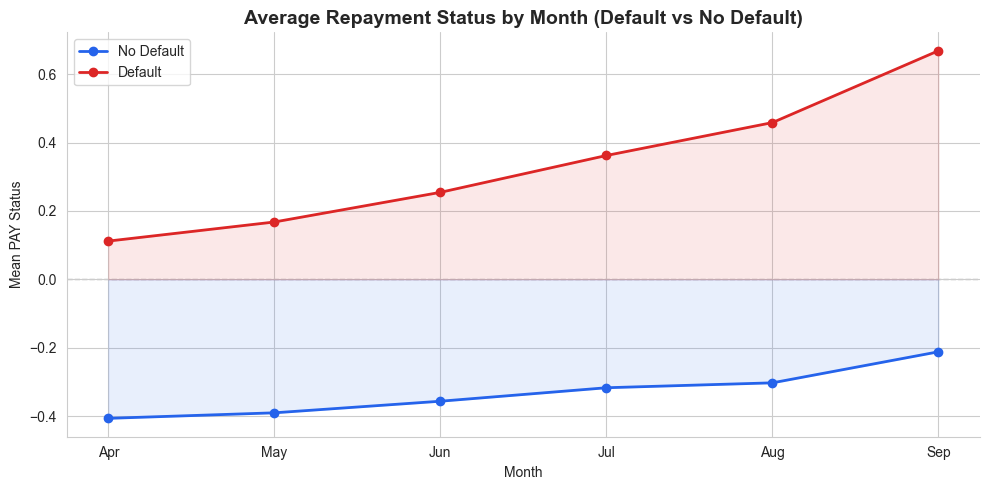

In [7]:
months = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
pay_cols = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']

mean_default = df[df['default'] == 1][pay_cols].mean()
mean_no_default = df[df['default'] == 0][pay_cols].mean()

plt.figure(figsize=(10, 5))

plt.plot(months, mean_no_default, label='No Default', color='#2563EB', marker='o', linewidth=2)
plt.plot(months, mean_default, label='Default', color='#DC2626', marker='o', linewidth=2)

plt.fill_between(months, mean_no_default, 0, color='#2563EB', alpha=0.1)
plt.fill_between(months, mean_default, 0, color='#DC2626', alpha=0.1)

plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=0)

plt.ylabel('Mean PAY Status')
plt.xlabel('Month')
plt.legend(loc='upper left')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title("Average Repayment Status by Month (Default vs No Default)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("output/monthly_repayment.png")
plt.show()

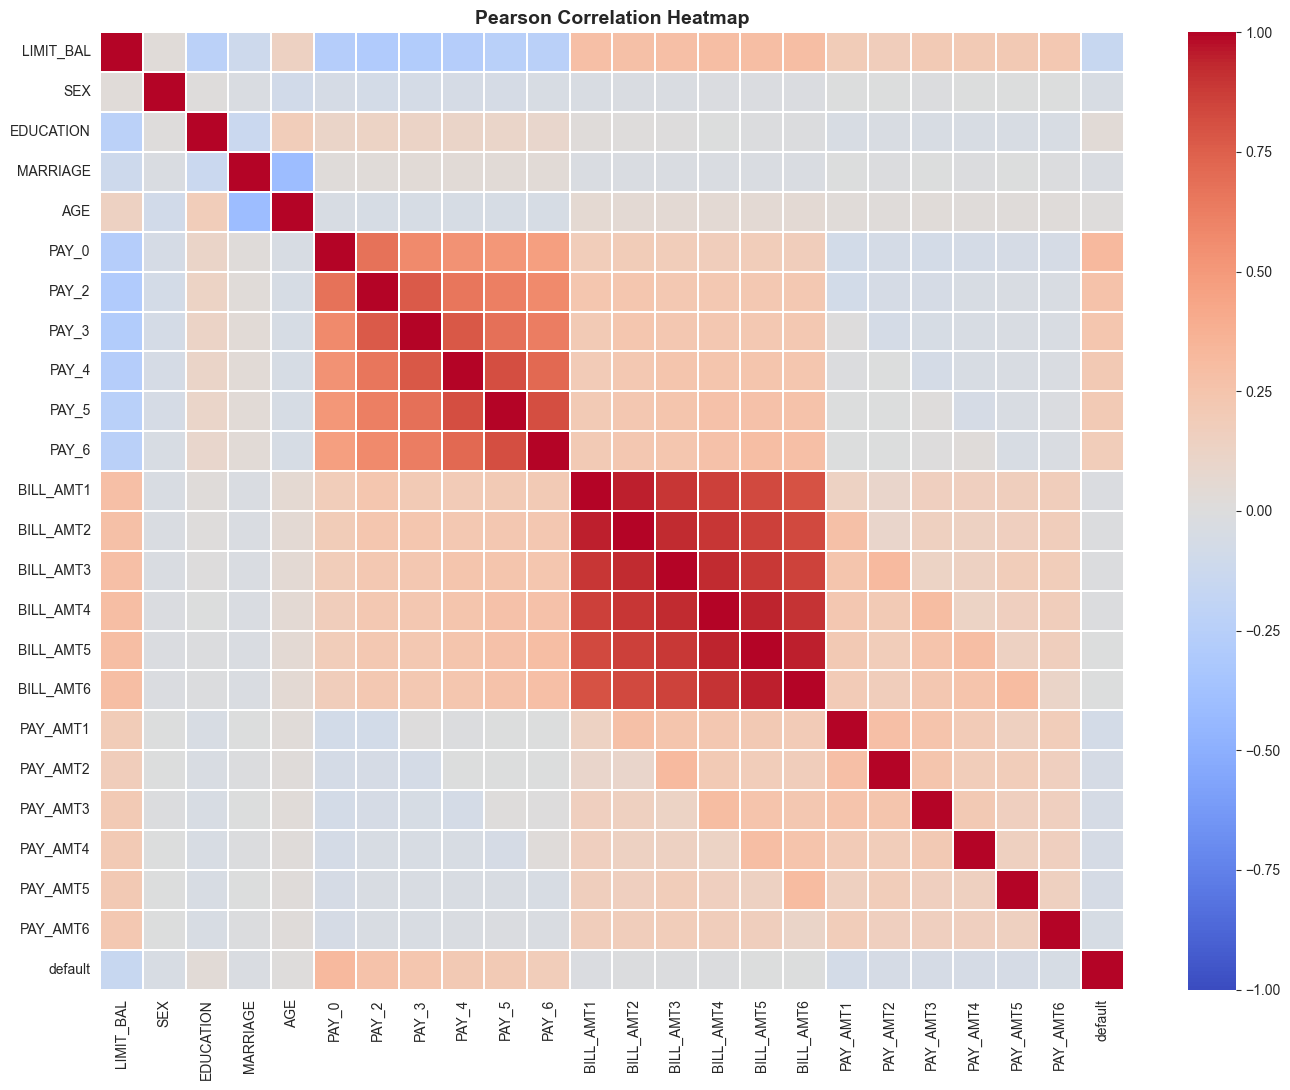

In [8]:
corr = df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False,
            linewidths=0.3, vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("output/pearson_correlation_heatmap.png", bbox_inches="tight")
plt.show()


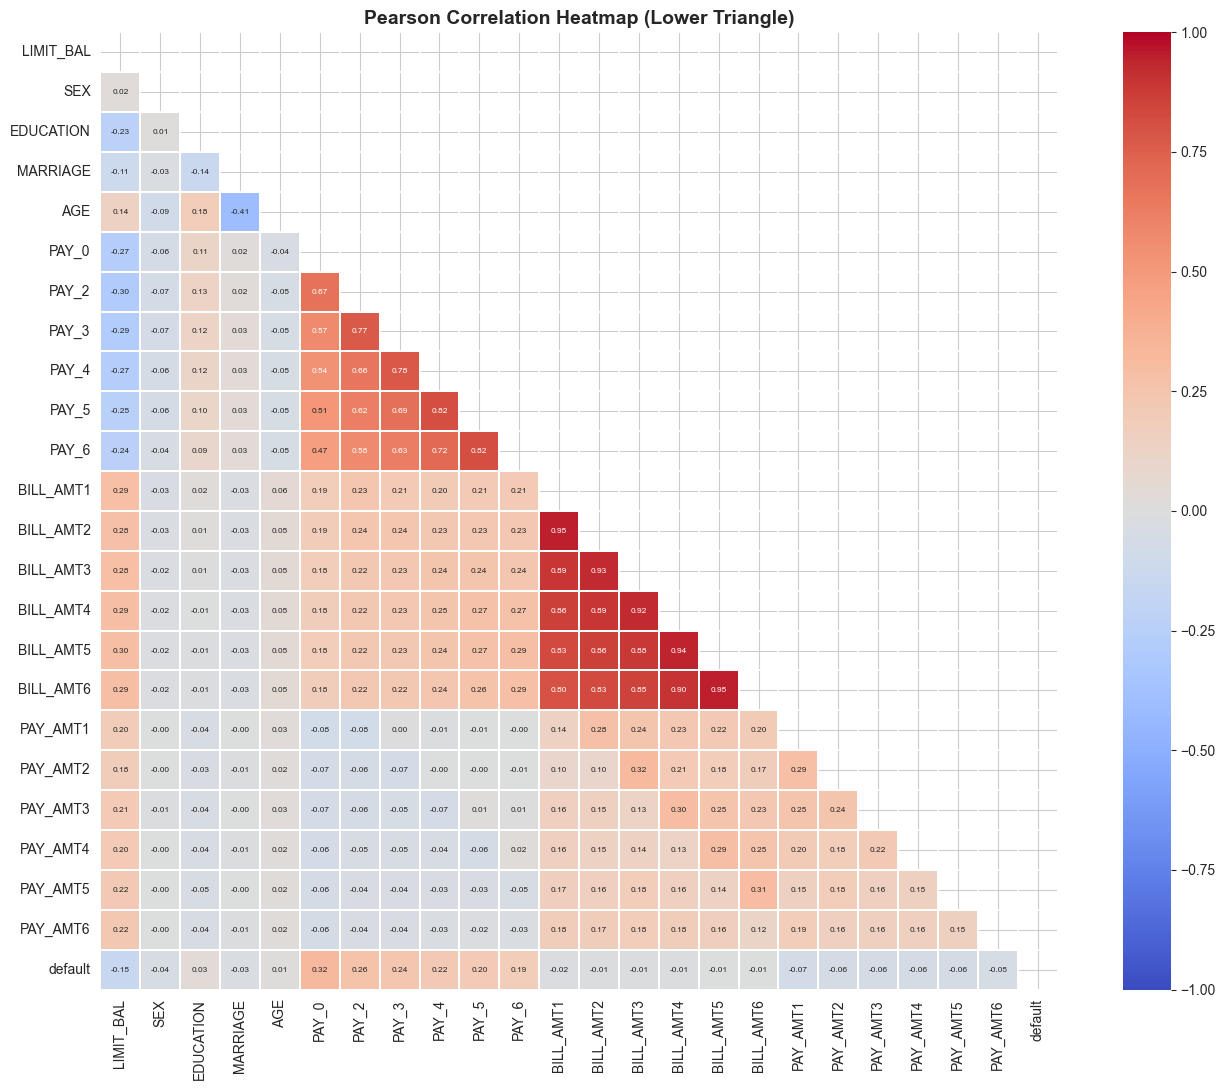

In [9]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle, show lower

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Pearson Correlation Heatmap (Lower Triangle)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("output/pearson_correlation_heatmap_triangle.png", bbox_inches="tight")
plt.show()


# Small Language Model (SLM)

#### Defining Feature Groups

In [10]:
STATIC_COLS = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]
PAY_COLS = ["PAY_6", "PAY_5", "PAY_4", "PAY_3", "PAY_2", "PAY_0"]
BILL_COLS = ["BILL_AMT6", "BILL_AMT5", "BILL_AMT4", "BILL_AMT3", "BILL_AMT2", "BILL_AMT1"]
AMT_COLS = ["PAY_AMT6", "PAY_AMT5", "PAY_AMT4", "PAY_AMT3", "PAY_AMT2", "PAY_AMT1"]
TARGET_COL = "default"
NUMERIC_STATIC_COLS = ["LIMIT_BAL", "AGE"]
MONTHLY_NUMERIC_COLS = BILL_COLS + AMT_COLS  # PAY_COLS excluded: ordinal ints cast back to int in Dataset


### Train-Test Split

In [11]:
# 70/15/15 split — train/val/test
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df[TARGET_COL]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df[TARGET_COL]
)

print(f"Train: {train_df.shape[0]:,}  Val: {val_df.shape[0]:,}  Test: {test_df.shape[0]:,}")


Train: 21,000  Val: 4,500  Test: 4,500


### Scaling Numerical Columns

In [12]:
scaler_static = StandardScaler()
scaler_monthly = StandardScaler()

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df[NUMERIC_STATIC_COLS] = scaler_static.fit_transform(train_df[NUMERIC_STATIC_COLS])
val_df[NUMERIC_STATIC_COLS]   = scaler_static.transform(val_df[NUMERIC_STATIC_COLS])
test_df[NUMERIC_STATIC_COLS]  = scaler_static.transform(test_df[NUMERIC_STATIC_COLS])

train_df[MONTHLY_NUMERIC_COLS] = scaler_monthly.fit_transform(train_df[MONTHLY_NUMERIC_COLS])
val_df[MONTHLY_NUMERIC_COLS]   = scaler_monthly.transform(val_df[MONTHLY_NUMERIC_COLS])
test_df[MONTHLY_NUMERIC_COLS]  = scaler_monthly.transform(test_df[MONTHLY_NUMERIC_COLS])


### Dataset Construction and Token Preparation

In [13]:
class CreditDataset(Dataset):
    def __init__(self, X, y=None):
        if hasattr(X, 'reset_index'):
            self.X = X.reset_index(drop=True)
        else:
            self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if hasattr(self.X, 'iloc'):
            row = self.X.iloc[idx]
        else:
            row = self.X[idx]

        static_num = torch.tensor(
            [row["LIMIT_BAL"], row["AGE"]],
            dtype=torch.float32
        )

        static_cat = torch.tensor(
            [int(row["SEX"]), int(row["EDUCATION"]), int(row["MARRIAGE"])],
            dtype=torch.long
        )

        monthly_num = []
        monthly_pay = []

        for p, b, a in zip(PAY_COLS, BILL_COLS, AMT_COLS):
            monthly_num.append([row[b], row[a]])
            monthly_pay.append(max(0, min(15, int(row[p]) + 2)))  # clamp to valid embedding range

        monthly_num = torch.tensor(monthly_num, dtype=torch.float32)
        monthly_pay = torch.tensor(monthly_pay, dtype=torch.long)

        X_dict = {
            "static_num": static_num,
            "static_cat": static_cat,
            "monthly_num": monthly_num,
            "monthly_pay": monthly_pay
        }
        
        if self.y is not None:
            val = self.y.iloc[idx] if hasattr(self.y, 'iloc') else self.y[idx]
            target = torch.tensor(val, dtype=torch.float32)
        else:
            target = torch.tensor(0.0, dtype=torch.float32)

        return X_dict, target


In [14]:
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]
X_val   = val_df.drop(columns=[TARGET_COL])
y_val   = val_df[TARGET_COL]
X_test  = test_df.drop(columns=[TARGET_COL])
y_test  = test_df[TARGET_COL]

train_dataset = CreditDataset(X_train, y_train)
val_dataset   = CreditDataset(X_val, y_val)
test_dataset  = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)


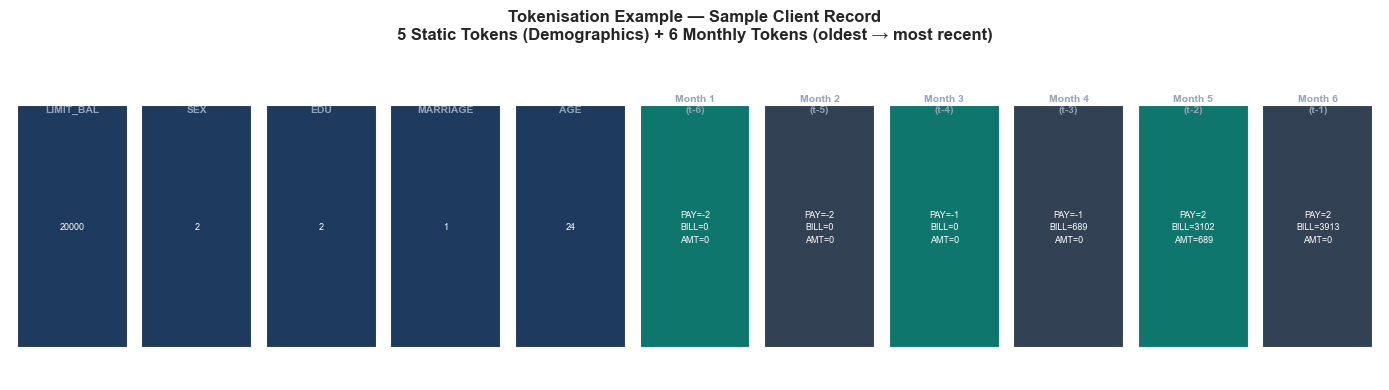

In [15]:
# Tokenisation Example — sample client record
sample = df.iloc[0]

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

pay_month  = ["PAY_6", "PAY_5", "PAY_4", "PAY_3", "PAY_2", "PAY_0"]
bill_month = ["BILL_AMT6", "BILL_AMT5", "BILL_AMT4", "BILL_AMT3", "BILL_AMT2", "BILL_AMT1"]
amt_month  = ["PAY_AMT6", "PAY_AMT5", "PAY_AMT4", "PAY_AMT3", "PAY_AMT2", "PAY_AMT1"]

tokens = [
    ("LIMIT_BAL",  f"{sample['LIMIT_BAL']:.0f}",             "#1E3A5F"),
    ("SEX",        f"{int(sample['SEX'])}",                   "#1E3A5F"),
    ("EDU",        f"{int(sample['EDUCATION'])}",             "#1E3A5F"),
    ("MARRIAGE",   f"{int(sample['MARRIAGE'])}",             "#1E3A5F"),
    ("AGE",        f"{int(sample['AGE'])}",                   "#1E3A5F"),
]
for i, (p, b, a) in enumerate(zip(pay_month, bill_month, amt_month)):
    tokens.append((
        f"Month {i+1}\n(t-{6-i})",
        f"PAY={int(sample[p])}\nBILL={sample[b]:.0f}\nAMT={sample[a]:.0f}",
        "#0F766E" if i % 2 == 0 else "#334155"
    ))

box_w = 1.0 / len(tokens) - 0.01
for idx, (label, val, color) in enumerate(tokens):
    x = idx * (1.0 / len(tokens)) + 0.005
    rect = plt.Rectangle((x, 0.1), box_w, 0.75,
                          transform=ax.transAxes,
                          facecolor=color, edgecolor="white", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + box_w / 2, 0.82, label, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=7.5, color="#94A3B8", fontweight="bold")
    ax.text(x + box_w / 2, 0.47, val, transform=ax.transAxes,
            ha="center", va="center", fontsize=6.5, color="white", linespacing=1.5)

ax.set_title(
    "Tokenisation Example — Sample Client Record\n"
    "5 Static Tokens (Demographics) + 6 Monthly Tokens (oldest → most recent)",
    fontweight="bold", fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig("output/tokenisation_example.png", bbox_inches="tight")
plt.show()


### Batch Structure Verification

In [16]:
batch = next(iter(train_loader))
inputs_dict, targets = batch
for k, v in inputs_dict.items():
    print(f"{k:12} : {v.shape}")
print(f"{'target':12} : {targets.shape}")

static_num   : torch.Size([128, 2])
static_cat   : torch.Size([128, 3])
monthly_num  : torch.Size([128, 6, 2])
monthly_pay  : torch.Size([128, 6])
target       : torch.Size([128])


### Multi Head Self-Attention Mechanism

In [17]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout = 0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = self.dropout(torch.softmax(scores, dim=-1))
        
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        out = self.W_o(context)

        return out, attn_weights

### Transformer Block Architecture

In [18]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)

In [19]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout = 0.1):
        super().__init__()

        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + self.dropout1(attn_out)

        ff_out = self.ff(self.norm2(x))
        x = x + self.dropout2(ff_out)

        return x, attn_weights

### Token Embedding and Transformation

In [20]:
class CreditTokenEmbedding(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        # Categorical static embeddings (one token each)
        # SEX: 1=male, 2=female → vocab 3 (indices 1-2)
        # EDUCATION: 1=grad, 2=univ, 3=HS, 4=others → vocab 5 (after remapping 0/5/6→4)
        # MARRIAGE: 1=married, 2=single, 3=others → vocab 4 (after remapping 0→3)
        self.sex_emb       = nn.Embedding(4, d_model)
        self.education_emb = nn.Embedding(5, d_model)
        self.marriage_emb  = nn.Embedding(4, d_model)

        # Numeric static projections (one token each)
        self.limit_bal_proj = nn.Linear(1, d_model)
        self.age_proj       = nn.Linear(1, d_model)

        # Monthly token construction
        self.monthly_num_proj = nn.Linear(2, d_model)
        self.pay_status_emb   = nn.Embedding(16, d_model)
        self.monthly_fusion   = nn.Linear(2 * d_model, d_model)

        self.dropout = nn.Dropout(0.1)

    def forward(self, static_num, static_cat, monthly_num, monthly_pay):
        # 5 static tokens — one per feature
        limit_bal_tok = self.limit_bal_proj(static_num[:, 0:1]).unsqueeze(1)
        age_tok       = self.age_proj(static_num[:, 1:2]).unsqueeze(1)
        sex_tok       = self.sex_emb(static_cat[:, 0]).unsqueeze(1)
        edu_tok       = self.education_emb(static_cat[:, 1]).unsqueeze(1)
        mar_tok       = self.marriage_emb(static_cat[:, 2]).unsqueeze(1)

        # 6 monthly tokens
        monthly_num_vec = self.monthly_num_proj(monthly_num)
        pay_vec         = self.pay_status_emb(monthly_pay)
        monthly_tokens  = self.monthly_fusion(
            torch.cat([monthly_num_vec, pay_vec], dim=-1)
        )

        # Sequence: [LIMIT_BAL, SEX, EDU, MARRIAGE, AGE, M1..M6] = 11 tokens
        tokens = torch.cat(
            [limit_bal_tok, sex_tok, edu_tok, mar_tok, age_tok, monthly_tokens], dim=1
        )
        return self.dropout(tokens)


In [21]:
class TemporalTransformer(nn.Module):
    def __init__(self, d_model = 64, n_heads = 4, n_layers = 2, d_ff = 128, dropout = 0.1):
        super().__init__()

        self.token_embedding = CreditTokenEmbedding(d_model)
        self.pos_emb = nn.Embedding(6, d_model)  # learned PE for 6 monthly tokens
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0, std=0.02)

    def _apply_pe(self, x):
        positions = torch.arange(6, device=x.device)
        static = x[:, :5, :]                             # 5 static tokens — no PE
        monthly = x[:, 5:, :] + self.pos_emb(positions) # 6 monthly tokens — learned PE
        return torch.cat([static, monthly], dim=1)

    def forward(self, static_num, static_cat, monthly_num, monthly_pay):
        x = self.token_embedding(static_num, static_cat, monthly_num, monthly_pay)
        x = self._apply_pe(x)

        for block in self.blocks:
            x, _ = block(x)

        x = self.final_norm(x)
        logits = self.classifier(x.mean(dim=1)).squeeze(-1)  # mean pool over all 11 tokens

        return logits

    def get_attention_maps(self, static_num, static_cat, monthly_num, monthly_pay):
        was_training = self.training
        self.eval()
        with torch.no_grad():
            x = self.token_embedding(static_num, static_cat, monthly_num, monthly_pay)
            x = self._apply_pe(x)

            attn_maps = []
            for block in self.blocks:
                x, attn_w = block(x)
                attn_maps.append(attn_w)

        self.train(was_training)
        return attn_maps


### Model Training and Tuning

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [23]:
torch.manual_seed(42)

X_df = train_df.drop(columns=[TARGET_COL])
y_series = train_df[TARGET_COL].values.astype('float32')

# Compute pos_weight from actual class ratio instead of guessing
pos_weight = torch.tensor([(y_series == 0).sum() / (y_series == 1).sum()]).to(device)

net = NeuralNetClassifier(
    TemporalTransformer,
    dataset=CreditDataset,
    module__d_model=64,
    module__n_heads=4,
    criterion=nn.BCEWithLogitsLoss,
    criterion__pos_weight=pos_weight,
    optimizer=optim.Adam,
    lr=0.001,
    max_epochs=50,
    batch_size=128,
    device=device,
    train_split=predefined_split(val_dataset),
    callbacks=[
        EarlyStopping(patience=5, monitor="valid_loss"),
        GradientNormClipping(gradient_clip_value=1.0),
    ],
)

# d_model and n_heads paired so head_dim=16 in both subspaces
shared_params = {
    "module__n_layers": [2, 3],
    "module__d_ff"    : [64, 128],
    "module__dropout" : [0.1, 0.2],
    "lr"              : [0.001, 0.0001],
}
param_grid = [
    {"module__d_model": [32], "module__n_heads": [2], **shared_params},
    {"module__d_model": [64], "module__n_heads": [4], **shared_params},
]

grid = RandomizedSearchCV(net, param_grid, n_iter=20, cv=3, scoring='f1_macro', random_state=42)
grid.fit(X_df, y_series)

print(f"Best Score: {grid.best_score_}")
print(f"Best Params: {grid.best_params_}")


  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.0242       0.6667        0.9348  8.6793


      2        0.9451       0.7260        0.9223  12.6329


      3        0.9235       0.7396        0.9107  11.1459


      4        0.9085       0.7587        0.9130  10.4944


      5        0.9005       0.7656        0.9140  10.9958


...

     13        0.8627       0.7502        0.8828  6.7565


     14        0.8622       0.7529        0.8859  6.6348


     15        0.8626       0.7576        0.8886  6.5473


     16        0.8601       0.7682        0.8893  6.8116


Stopping since valid_loss has not improved in the last 5 epochs.
Best Score: 0.6916666211139564
Best Params: {'module__n_layers': 2, 'module__n_heads': 4, 'module__dropout': 0.1, 'module__d_model': 64, 'module__d_ff': 64, 'lr': 0.001}


### Final Result

In [24]:
y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]

y_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

auc = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {auc:.4f}")

              precision    recall  f1-score   support

  No Default       0.88      0.78      0.83      3504
     Default       0.45      0.64      0.53       996

    accuracy                           0.75      4500
   macro avg       0.67      0.71      0.68      4500
weighted avg       0.79      0.75      0.76      4500

ROC-AUC Score: 0.7810


In [25]:
# Conservative Prediction
custom_threshold = 0.3

y_pred_conservative = (y_probs > custom_threshold).astype(int)
print(classification_report(y_test, y_pred_conservative, target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.93      0.38      0.54      3504
     Default       0.29      0.90      0.44       996

    accuracy                           0.50      4500
   macro avg       0.61      0.64      0.49      4500
weighted avg       0.79      0.50      0.52      4500



In [26]:
grid.best_estimator_.save_params(f_params='output/SLM_model_weights.pt')

### Visualisation

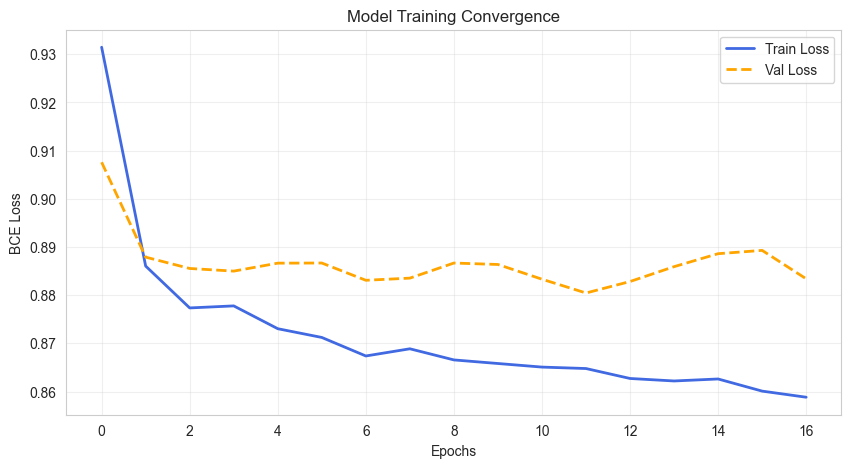

In [27]:
history = grid.best_estimator_.history

plt.figure(figsize=(10, 5))
plt.plot(history[:, 'train_loss'], label='Train Loss', color='royalblue', lw=2)
plt.plot(history[:, 'valid_loss'], label='Val Loss',   color='orange',    lw=2, linestyle='--')
plt.title('Model Training Convergence')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('output/SLM_loss.png')
plt.show()


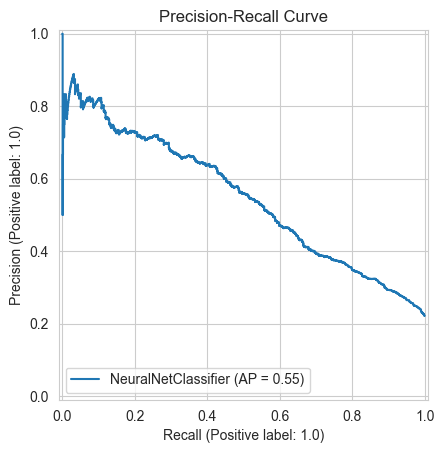

In [28]:
PrecisionRecallDisplay.from_estimator(grid.best_estimator_, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.savefig("output/SLM_precision_recall.png")
plt.show()

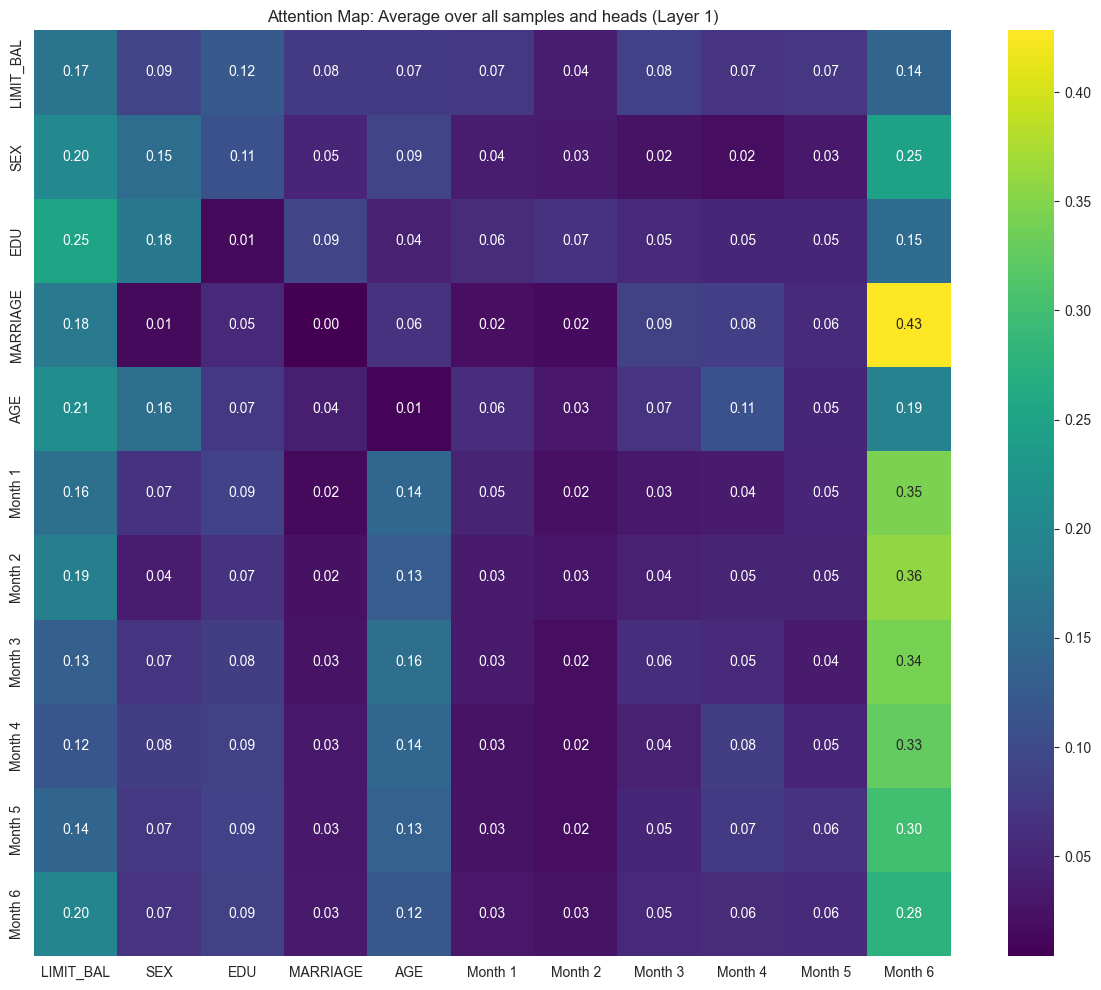

In [29]:
batch = next(iter(test_loader))
inputs_dict, _ = batch
device = grid.best_estimator_.device

s_num = inputs_dict['static_num'].to(device)
s_cat = inputs_dict['static_cat'].to(device)
m_num = inputs_dict['monthly_num'].to(device)
m_pay = inputs_dict['monthly_pay'].to(device)

attn_weights = grid.best_estimator_.module_.get_attention_maps(s_num, s_cat, m_num, m_pay)

# Average over all samples and all heads for a population-level view
# attn_weights[0] shape: [batch, heads, seq, seq]
heatmap_data = attn_weights[0].mean(dim=(0, 1)).detach().cpu().numpy()

labels = ['LIMIT_BAL', 'SEX', 'EDU', 'MARRIAGE', 'AGE'] + [f'Month {i}' for i in range(1, 7)]

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels, cmap='viridis')
plt.title('Attention Map: Average over all samples and heads (Layer 1)')
plt.tight_layout()
plt.savefig("output/SLM_attention.png", bbox_inches='tight')
plt.show()


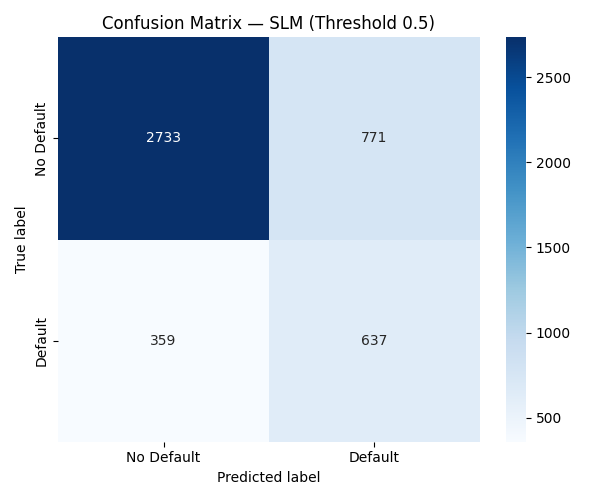

In [ ]:
y_pred = grid.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix — SLM (Threshold 0.5)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig("output/SLM_confusion_matrix.png")
plt.show()

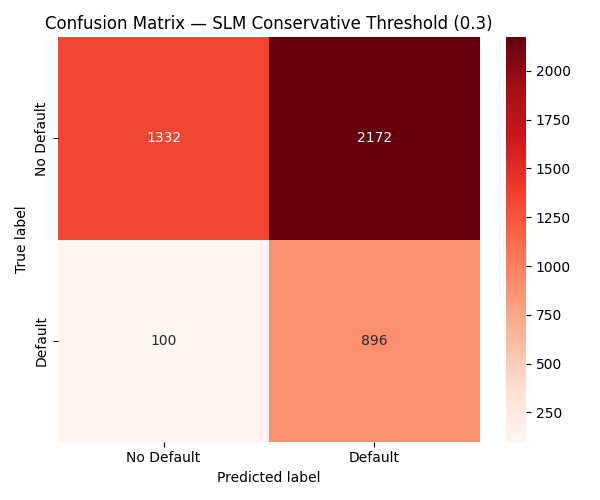

In [ ]:
# Confusion Matrix — Conservative Threshold (0.3)
cm_conservative = confusion_matrix(y_test, y_pred_conservative)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_conservative, annot=True, fmt='d', cmap='Reds', linewidths=0,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix — SLM Conservative Threshold (0.3)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig("output/SLM_confusion_matrix_conservative.png")
plt.show()

# Benchmark - Random Forest

### Using Raw Data

In [32]:
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

In [33]:
param_grid = {
    'n_estimators': [75, 100, 125],
    'max_depth': [15, 20, 25],
    'min_samples_split': [8, 10, 12]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train.values.ravel())

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

final_preds = best_rf.predict(X_test)

print("--- Final GridSearchCV Random Forest Report ---")
print(classification_report(y_test, final_preds))

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best Parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 125}
Best CV Score (F1): 0.6859
--- Final GridSearchCV Random Forest Report ---
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      3504
           1       0.65      0.35      0.46       996

    accuracy                           0.82      4500
   macro avg       0.74      0.65      0.67      4500
weighted avg       0.80      0.82      0.79      4500



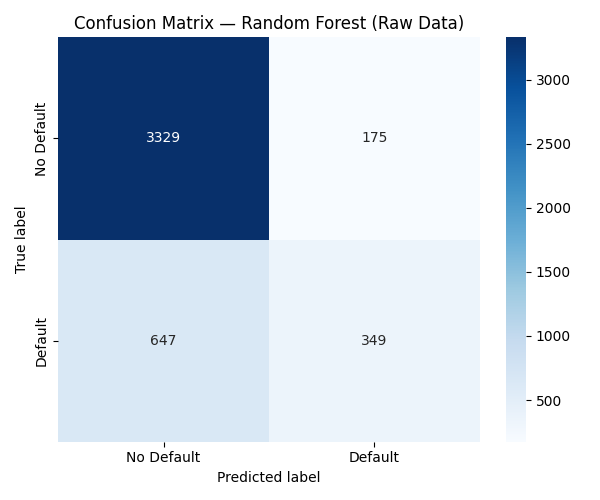

In [ ]:
# ROC-AUC — Random Forest (Raw Data)
rf_probs = best_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, rf_probs)
print(f"ROC-AUC Score (RF Raw Data): {auc_rf:.4f}")

# Confusion Matrix — Random Forest (Raw Data)
cm_rf = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', linewidths=0,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix — Random Forest (Raw Data)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig("output/RF_raw_confusion_matrix.png")
plt.show()

In [35]:
joblib.dump(grid_search.best_estimator_, 'output/raw_data_RF_model.joblib')

['output/raw_data_RF_model.joblib']

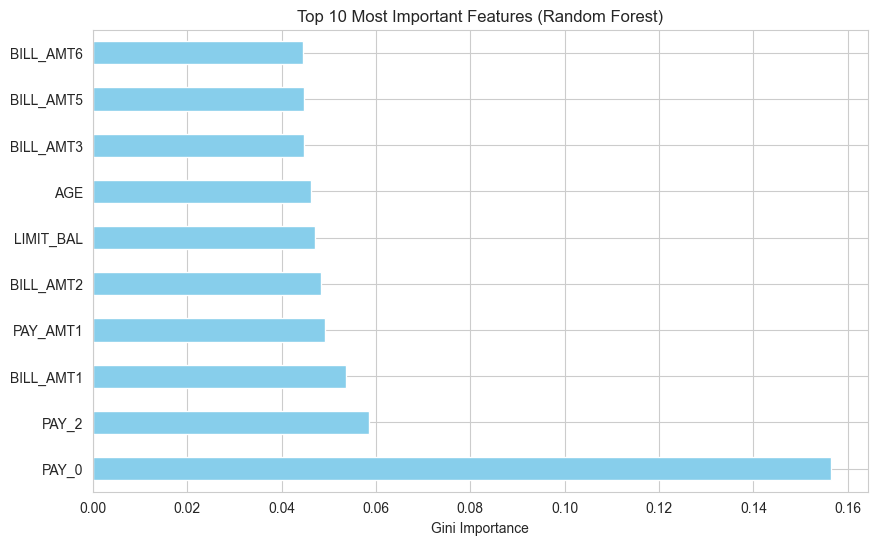

In [36]:
importances = best_rf.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Token_Dim_{i}' for i in range(len(importances))]

feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Gini Importance")
plt.savefig("output/raw_data_RF_feacture_importance.png")
plt.show()

### Using Tokenised Data

In [37]:
torch.manual_seed(42)

d_model = 64
tokeniser = CreditTokenEmbedding(d_model)
tokeniser.eval()

def get_tokens(dataloader):
    all_tokens = []
    with torch.no_grad():
        for batch in dataloader:
            inputs, _ = batch
            tokens = tokeniser(
                inputs['static_num'],
                inputs['static_cat'],
                inputs['monthly_num'],
                inputs['monthly_pay']
            )
            flattened = tokens.view(tokens.size(0), -1)
            all_tokens.append(flattened.numpy())
            
    return np.concatenate(all_tokens, axis=0)

X_train_tokenised = get_tokens(train_loader)
X_test_tokenised = get_tokens(test_loader)

In [38]:
grid_search_tokenised = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1
)

grid_search_tokenised.fit(X_train_tokenised, y_train.values.ravel())

print(f"Best Parameters: {grid_search_tokenised.best_params_}")
print(f"Best CV Score (F1): {grid_search_tokenised.best_score_:.4f}")

best_rf_tokenised = grid_search_tokenised.best_estimator_

final_preds_tokenised = best_rf_tokenised.predict(X_test_tokenised)

print("--- Final GridSearchCV Random Forest Report ---")
print(classification_report(y_test, final_preds_tokenised))

Best Parameters: {'max_depth': 25, 'min_samples_split': 12, 'n_estimators': 100}
Best CV Score (F1): 0.4405
--- Final GridSearchCV Random Forest Report ---
              precision    recall  f1-score   support

           0       0.78      1.00      0.87      3504
           1       0.30      0.00      0.01       996

    accuracy                           0.78      4500
   macro avg       0.54      0.50      0.44      4500
weighted avg       0.67      0.78      0.68      4500



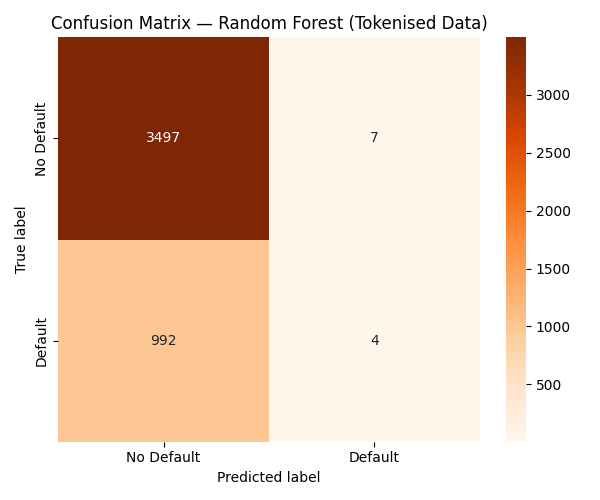

In [ ]:
# ROC-AUC — Random Forest (Tokenised Data)
rf_tok_probs = best_rf_tokenised.predict_proba(X_test_tokenised)[:, 1]
auc_rf_tok = roc_auc_score(y_test, rf_tok_probs)
print(f"ROC-AUC Score (RF Tokenised): {auc_rf_tok:.4f}")

# Confusion Matrix — Random Forest (Tokenised Data)
cm_rf_tok = confusion_matrix(y_test, final_preds_tokenised)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_tok, annot=True, fmt='d', cmap='Oranges', linewidths=0,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix — Random Forest (Tokenised Data)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig("output/RF_tokenised_confusion_matrix.png")
plt.show()

In [40]:
joblib.dump(grid_search_tokenised.best_estimator_, 'output/tokenised_data_RF_model.joblib')

['output/tokenised_data_RF_model.joblib']

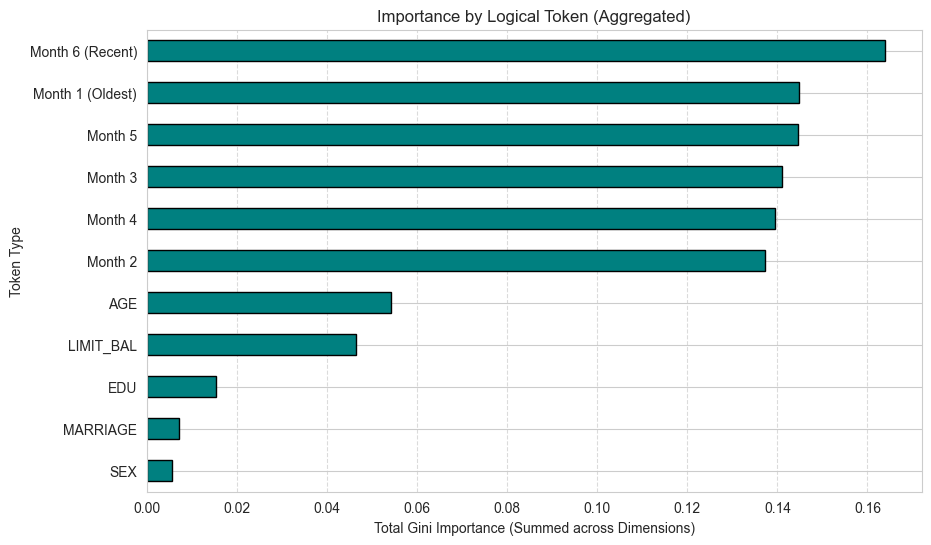

In [41]:
labels = [
    'LIMIT_BAL',
    'SEX',
    'EDU',
    'MARRIAGE',
    'AGE',
    'Month 1 (Oldest)',
    'Month 2',
    'Month 3',
    'Month 4',
    'Month 5',
    'Month 6 (Recent)'
]

raw_importances = best_rf_tokenised.feature_importances_
aggregated_importance = []
for i in range(len(labels)):
    start_idx = i * d_model
    end_idx = (i + 1) * d_model
    token_sum = np.sum(raw_importances[start_idx:end_idx])
    aggregated_importance.append(token_sum)

token_importance_series = pd.Series(aggregated_importance, index=labels)
token_importance_series = token_importance_series.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
token_importance_series.plot(kind='barh', color='teal', edgecolor='black')
plt.title("Importance by Logical Token (Aggregated)")
plt.xlabel("Total Gini Importance (Summed across Dimensions)")
plt.ylabel("Token Type")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("output/tokenised_data_RF_feacture_importance.png")
plt.show()
